In [1]:
import tensorflow as tf

In [2]:
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt

In [3]:
mnist = keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train,x_test = x_train/255.0,x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


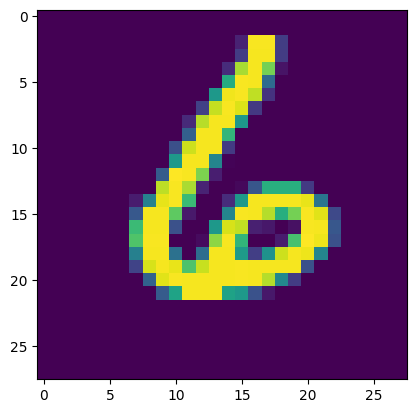

In [4]:
plt.imshow(x_train[9943])


In [5]:
xtrain=x_train

In [6]:
model=keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history=model.fit(xtrain,y_train,validation_split=0.1,epochs=30)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9228 - loss: 0.2737 - val_accuracy: 0.9648 - val_loss: 0.1303
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9638 - loss: 0.1228 - val_accuracy: 0.9718 - val_loss: 0.0972
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9751 - loss: 0.0820 - val_accuracy: 0.9737 - val_loss: 0.0866
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9810 - loss: 0.0614 - val_accuracy: 0.9778 - val_loss: 0.0798
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9853 - loss: 0.0481 - val_accuracy: 0.9753 - val_loss: 0.0868
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9884 - loss: 0.0383 - val_accuracy: 0.9797 - val_loss: 0.0746
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accuracy: 0.9787 - val_loss: 0.0783
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9929 - loss: 0.0239 - 

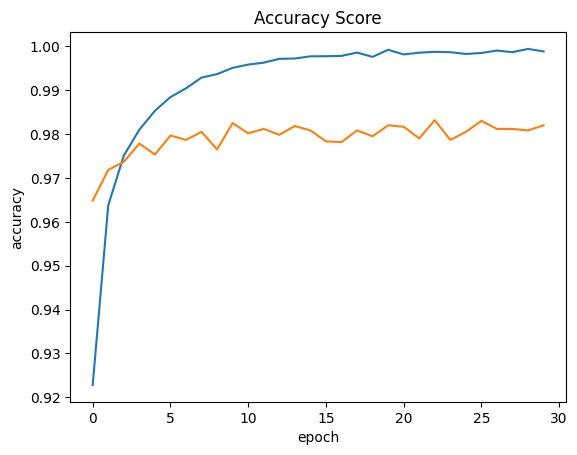

In [9]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='epoch')
plt.title("Accuracy Score")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

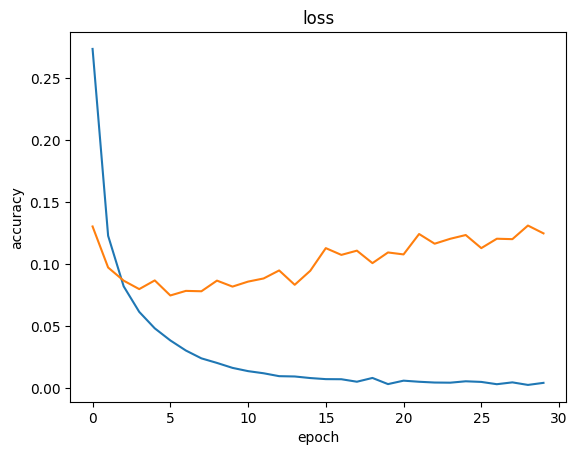

In [10]:
plt.plot(history.history['loss'],label='Accuracy')
plt.plot(history.history['val_loss'],label='epoch')
plt.title("loss")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [11]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [12]:
y_pred[9999]

array([1.04591148e-20, 1.34523327e-27, 2.65035745e-20, 5.17696560e-21,
       1.81301033e-17, 4.67336043e-21, 9.99999940e-01, 1.10958414e-29,
       1.79676630e-27, 2.02201354e-30], dtype=float32)

In [13]:
import numpy as np
y_pred1=np.argmax(y_pred,axis=1)
y_pred1[111]

np.int64(7)

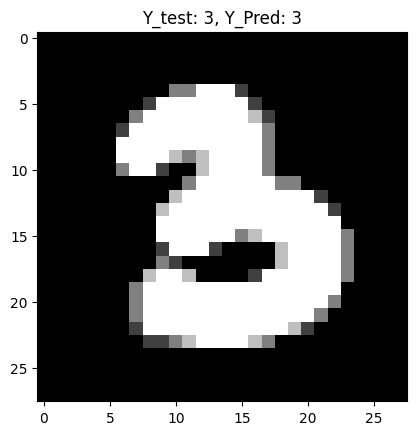

In [14]:
plt.imshow(x_test[894],cmap='gray')
plt.title(f"Y_test: {y_test[894]}, Y_Pred: {y_pred1[894]}")
plt.show()

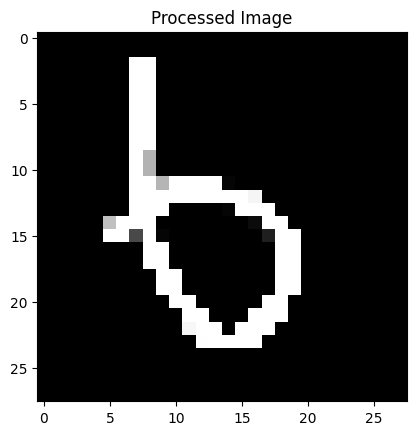

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Digit: 6
Confidence: 1.0


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-06-08 220036.png", cv2.IMREAD_GRAYSCALE)

img1 = cv2.resize(img, (28, 28))

# Invert colors if digit is black on white background
img2 = 255 - img1

# Normalize
img3 = img2 / 255.0

# Display processed image
plt.imshow(img3, cmap='gray')
plt.title("Processed Image")
plt.show()

# Reshape for model
img4 = img3.reshape(1, 28, 28)

# Prediction
y_pred = model.predict(img4)

# Predicted digit
digit = np.argmax(y_pred)

print("Predicted Digit:", digit)
print("Confidence:", np.max(y_pred))

In [17]:
model.save('mnist_model.h5')